In [2]:
import sys
sys.path.insert(0, "/home/zbezjak/code/donismous/Climate-Resilience")  # repo root
import os
os.chdir("/home/zbezjak/code/donismous/Climate-Resilience")

import warnings
import numpy as np
import pandas as pd

from model.composite_risk_score import compute_composite_risk
from model.basic_arima_model import fit_arima, prepare_series
from model.basic_arima_model import forecast as arima_forecast
from model.exp_smoothing import fit_ets
from model.exp_smoothing import forecast as ets_forecast

TEST_YEARS = 5
MIN_TRAIN_POINTS = 10

In [3]:
def _metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    errors = predicted - actual
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors**2))
    mape = np.nan if np.any(actual == 0) else np.mean(np.abs(errors / actual)) * 100
    return {"mae": mae, "rmse": rmse, "mape": mape}

def backtest_one_country(series, test_years=TEST_YEARS):
    if len(series) < MIN_TRAIN_POINTS + test_years:
        return {"arima": None, "ets": None}
    train, test = series.iloc[:-test_years], series.iloc[-test_years:]
    result = {"arima": None, "ets": None}
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            pred = arima_forecast(fit_arima(train), steps=test_years)
            result["arima"] = _metrics(test.values, pred["forecast"].values)
        except Exception as exc:
            result["arima"] = {"error": str(exc)}
        try:
            pred = ets_forecast(fit_ets(train), steps=test_years)
            result["ets"] = _metrics(test.values, pred["forecast"].values)
        except Exception as exc:
            result["ets"] = {"error": str(exc)}
    return result

def run_backtest(risk_df, test_years=TEST_YEARS, countries=None):
    if countries is None:
        countries = sorted(risk_df["country"].unique())
    rows = []
    for country in countries:
        try:
            series = prepare_series(risk_df, country)
        except ValueError:
            continue
        result = backtest_one_country(series, test_years=test_years)
        if result["arima"] is None and result["ets"] is None:
            continue
        for model_name in ("arima", "ets"):
            m = result[model_name]
            if m is None:
                continue
            rows.append({"country": country, "model": model_name,
                         "mae": m.get("mae"), "rmse": m.get("rmse"),
                         "mape": m.get("mape"), "error": m.get("error")})
    return pd.DataFrame(rows)

def summarize_backtest(backtest_df):
    valid = backtest_df[backtest_df["error"].isna()]
    failed = backtest_df[backtest_df["error"].notna()].groupby("model").size()
    summary = valid.groupby("model").agg(
        mean_mae=("mae", "mean"), median_mae=("mae", "median"),
        mean_rmse=("rmse", "mean"), median_rmse=("rmse", "median"),
        mean_mape=("mape", "mean"), median_mape=("mape", "median"),
        n_countries=("mae", "count"),
    )
    summary["n_failed"] = failed.reindex(summary.index).fillna(0).astype(int)
    return summary

def head_to_head_win_rate(backtest_df):
    valid = backtest_df[backtest_df["error"].isna()]
    pivot = valid.pivot(index="country", columns="model", values="mae").dropna()
    winner = np.where(pivot["arima"] < pivot["ets"], "arima",
                       np.where(pivot["arima"] > pivot["ets"], "ets", "tie"))
    return pd.Series(winner).value_counts()

In [4]:
df = pd.read_csv("data/data_preprocessed/processed_data.csv")
risk_df = compute_composite_risk(df)

backtest = run_backtest(risk_df, test_years=5)
summary = summarize_backtest(backtest)
summary

ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(1, 0, 3) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(2, 0, 3) did not converge, falling back to ARIMA(2, 0, 0)
ARIMA(1, 0, 3) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(1, 0, 3) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(3, 0, 2) did not converge, falling back to ARIMA(3, 0, 0)
ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(2, 0, 4) did not converge, falling back to ARIMA(2, 0, 0)
ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(1, 0, 3) did not converge, falling

,mean_mae,median_mae,mean_rmse,median_rmse,mean_mape,median_mape,n_countries,n_failed
model,,,,,,,,
arima,0.009312,0.007423,0.010183,0.008133,1.937891,1.409515,186,0
ets,0.009309,0.007823,0.010301,0.008502,1.962576,1.597662,186,0


In [5]:
head_to_head_win_rate(backtest)

ets      97
arima    89
Name: count, dtype: int64

In [7]:
import os
print(os.getcwd())

/home/zbezjak/code/donismous/Climate-Resilience


In [9]:
arima_df = pd.read_csv("data/outputs/risk_score_with_forecast.csv")
ets_df = pd.read_csv("data/outputs/risk_score_with_ets_forecast.csv")

arima_fc = arima_df[arima_df["source"] == "forecast"][["country", "year", "risk_score", "lower", "upper"]] \
    .rename(columns={"risk_score": "arima_forecast", "lower": "arima_lower", "upper": "arima_upper"})
ets_fc = ets_df[ets_df["source"] == "forecast"][["country", "year", "risk_score", "lower", "upper"]] \
    .rename(columns={"risk_score": "ets_forecast", "lower": "ets_lower", "upper": "ets_upper"})

merged = arima_fc.merge(ets_fc, on=["country", "year"]).sort_values(["country", "year"])
merged["diff"] = merged["ets_forecast"] - merged["arima_forecast"]

merged.groupby("year").apply(lambda g: pd.Series({
    "mean_abs_diff": g["diff"].abs().mean(),
    "correlation": g["arima_forecast"].corr(g["ets_forecast"]),
}))

/tmp/ipykernel_48994/3948546375.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged.groupby("year").apply(lambda g: pd.Series({


,mean_abs_diff,correlation
year,,
2024,0.012190,0.994152
2025,0.011815,0.993348
2026,0.011860,0.992281
2027,0.012351,0.990954
2028,0.013064,0.989473
2029,0.014028,0.987858
2030,0.015125,0.986126


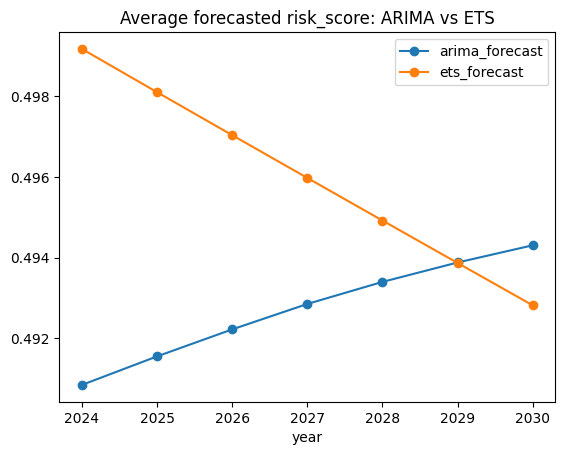

In [10]:
import matplotlib.pyplot as plt

by_year = merged.groupby("year")[["arima_forecast", "ets_forecast"]].mean()
by_year.plot(marker="o", title="Average forecasted risk_score: ARIMA vs ETS")
plt.show()